# Proyek Analisis Data: Bike Sharing Dataset

## Menentukan Pertanyaan Bisnis

**SMART Question** adalah sebuah framework untuk merumuskan pertanyaan secara terstruktur agar memeperoleh informasi yang mendalam.

* **Spesific (Spesifik)**
  * Pertanyaan harus jelas, fokus pada sebuah topik tertentu, dan tidak bermakna ganda. Hindari pertanyaan yang terlalu luas.
    * Salah: Bagaimana cara meningkatkan penjualan?
    * Benar: Faktor apa saja yang memengaruhi penurunan penjualan produk kategori elektronik di wilayah Jakarta selama kuartal terakhir?
* **Measurable (Terukur)**
  * Pertanyaan harus bisa dijawab dengan angka atau matrix yang konkret, harus tahu apa yang akan dihitung.
    * Salah: Apakah pelanggan senang dengan layanan kita?
    * Benar: Berapa skor rata-rata Customer Satisfaction untuk layanan purna jual bulan ini dibandingkan bulan lalu?
* **Action-Oriented (Berorientasi Aksi)**
  * Hasil dari pertanyaan harus bisa memberikan arahan untuk melakukan tindakan nyata. Jika pertanyaan terjawab, stakeholder harus tahu apa langkah selanjutnya.
    * Salah: Mengapa orang suka berbelanja?
    * Benar: Fitur apa pada aplikasi yang paling sering digunakan sebelum pengguna memutuskan untuk melakukan checkout?
* **Relevant (Relevan)**
  * Hasil dari pertanyaan harus sejalan dengan tujuan utama bisnis atau masalah yang sedang dihadapi.
    * Salah: Menanyakan tentang stok gudang saat masalah utamanya adalah efektivitas kampanye media sosial.
    * Benar: Apakah kampanye iklan di Instagram memberikan Return on Ad Spend (ROAS) yang lebih tinggi dibandingkan iklan di TikTok?
* **Time-bound (Terikat Waktu)**
  * Pertanyaan harus ada batasan waktu yang jelas agar analisis memiliki konteks yang tepat.
    * Salah: Berapa banyak pengguna baru kita?
    * Benar: Berapa tingkat pertumbuhan pengguna baru secara bulanan (Month-over-Month) sepanjang tahun 2025?

**Contoh pertanyaan bisnis yang memenuhi seluruh elemen SMART**

***"Faktor apa saja yang memengaruhi penurunan conversion rate pada pengguna aplikasi Android di wilayah Jabodetabek sebesar 5% selama periode Flash Sale Maret 2026?"***

Keterangan:

- **Specific**: Fokus pada "penurunan conversion rate" untuk "aplikasi Android" di "Jabodetabek". Bukan sekadar penjualan turun.
- **Measurable**: Ada angka konkret yang ingin dianalisis, yaitu penurunan sebesar "5%".
- **Action-Oriented**: Dengan mengetahui faktor penyebabnya misalnya bug pada versi Android tertentu atau kendala logistik di Jabodetabek, tim bisa langsung melakukan perbaikan teknis atau operasional.
- **Relevant**: Penurunan konversi saat Flash Sale adalah masalah kritis bagi bisnis retail/e-commerce.
- **Time-bound**: Dibatasi pada periode spesifik "Flash Sale Maret 2026".


- **Pertanyaan 1:** Bagaimana tren jumlah penyewaan sepeda per bulan selama tahun 2012 dibandingkan dengan tahun 2011, dan pada bulan apa terjadi kenaikan tertinggi?
- **Pertanyaan 2:** Berapakah rata-rata penurunan jumlah penyewa sepeda saat kondisi cuaca buruk (weathersit 3 & 4) dibandingkan cuaca cerah di hari kerja selama seluruh periode data?
- **Pertanyaan 3:** Pada jam berapa puncak penyewaan terjadi pada hari kerja (working day) dibandingkan akhir pekan, dan apakah polanya konsisten di setiap musim selama periode pengamatan 2011-2012?
- **Pertanyaan 4:** Bagaimana dampak hari libur nasional (holiday) terhadap total distribusi peminjaman dibandingkan hari biasa pada periode tahun 2011-2012?
- **Pertanyaan 5:** Bagaimana segmentasi hari berdasarkan intensitas penggunaan (Monetary), frekuensi penggunaan pada puncak musim (Frequency), dan kapan terakhir kali terjadi lonjakan penyewaan (Recency) pada tahun 2012?


## Import Semua Packages/Library yang Digunakan

In [136]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import skew
from google.colab import files

## Data Wrangling

### Gathering Data

#### Load df day.csv

In [137]:
day_df = pd.read_csv('day.csv')
day_df

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
726,727,2012-12-27,1,1,12,0,4,1,2,0.254167,0.226642,0.652917,0.350133,247,1867,2114
727,728,2012-12-28,1,1,12,0,5,1,2,0.253333,0.255046,0.590000,0.155471,644,2451,3095
728,729,2012-12-29,1,1,12,0,6,0,2,0.253333,0.242400,0.752917,0.124383,159,1182,1341
729,730,2012-12-30,1,1,12,0,0,0,1,0.255833,0.231700,0.483333,0.350754,364,1432,1796


**Insight:**
Dataset day.csv berisi data historis harian mengenai penyewaan sepeda dari sistem Capital Bikeshare di Washington D.C. Dataset ini berisi data per hari yang terdiri dari 731 data. Dataset ini memisahkan antara pengguna casual dan registered (pengguna rutin/komuter) yang biasanya memiliki pola perilaku berbeda terhadap cuaca atau hari kerja.<p>

Berikut rincian kolom-kolomnya:
- **Instant:** merupakan indeks catatan atau nomor urut baris.
- **dteday:** berisi tanggal pencatatan data.
- **season:** berisi musim saat tanggal pencatatan, dengan rincian musimnya:
  - 1: Musim Dingin (Winter)
  - 2: Musim Semi (Spring)
  - 3: Musim Panas (Summer)
  - 4: Musim Gugur (Fall)
- **yr:** berisi tahun saat tanggal pencatatan.
- **mnth:** berisi bulan saat tanggal pencatatan.
- **holiday:** berisi apakah hari tersebut merupakan hari libur atau tidak saat tanggal pencatatan (berdasarkan jadwal hari libur resmi).
- **weekday:** berisi hari dalam seminggu (0 hingga 6).
- **workingday:** berisi apakah hari saat tanggal pencatatan merupakan hari kerja atau weekend/hari libur, dengan nilai:
  - 1: hari kerja
  - 0: hari libur/weekend
- **weahersit:** berisi situasi cuaca saat tanggal pencatatan:
  - 1: Cerah/Sedikit Berawan (Clear/Partly Cloudy)
  - 2: Kabut/Berawan (Misty/Cloudy)
  - 3: Salju ringan/Hujan ringan (Light Snow/Rain)
  - 4: Hujan lebat/Badai (Heavy Rain/Snow)
- **temp:** berisi suhu saat tanggal pencatatan yang sudah dinormalisasi dalam Celsius (nilainya dibagi dengan 41 (maks))
- **atemp:** berisi suhu perasaan saat tanggal pencatatan yang dinormalisasi dalam Celsius (nilainya dibagi dengan 50 (maks))
- **hum:** berisi kelembaban pada tanggal pencatatan yang dinormalisasi (nilainya dibagi dengan 100 (maks))
- **windspeed:** berisi kecepatan angin pada tanggal pencatatan yang dinormalisasi (nilainya dibagi dengan 67 (maks))
- **casual:** berisi jumlah pengguna biasa yang menyewa sepeda pada tanggal pencatatan.
- **registered:** berisi jumlah pengguna terdaftar/member yang menyewa sepeda pada tanggal pencatatan.
- **cnt:** berisi total penyewaan/gabungan antara pengguna *casual* dan *registered*.

Variabel target adalah kolom **casual**, **registered**, **cnt**.

#### Load df hour.csv

In [138]:
hour_df = pd.read_csv('hour.csv')
hour_df

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0000,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0000,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0000,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0000,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0000,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17374,17375,2012-12-31,1,1,12,19,0,1,1,2,0.26,0.2576,0.60,0.1642,11,108,119
17375,17376,2012-12-31,1,1,12,20,0,1,1,2,0.26,0.2576,0.60,0.1642,8,81,89
17376,17377,2012-12-31,1,1,12,21,0,1,1,1,0.26,0.2576,0.60,0.1642,7,83,90
17377,17378,2012-12-31,1,1,12,22,0,1,1,1,0.26,0.2727,0.56,0.1343,13,48,61


**Insight:**
Dataset hour.csv berisi data historis per jam mengenai penyewaan sepeda dari sistem Capital Bikeshare di Washington D.C setiap harinya. Dataset ini terdiri dari 17379 data. Dataset ini dapat dipakai untuk melihat pola penggunaan sepeda berdasarkan waktu sibuk (rush hour) atau perubahan cuaca yang drastis dalam satu hari.<p>

Berikut rincian kolom-kolomnya:
- **Instant:** merupakan indeks catatan atau nomor urut baris.
- **dteday:** berisi tanggal pencatatan data.
- **season:** berisi musim saat tanggal pencatatan, dengan rincian musimnya:
  - 1: Musim Dingin
  - 2: Musim Semi
  - 3: Musim Panas
  - 4: Musim Gugur
- **yr:** berisi tahun saat tanggal pencatatan.
- **mnth:** berisi bulan saat tanggal pencatatan.
- **hr:** am dalam satu hari (0 sampai 23). *Ini adalah kolom pembeda utama dari dataset harian.*
- **holiday:** berisi apakah hari tersebut merupakan hari libur atau tidak saat tanggal pencatatan (berdasarkan jadwal hari libur resmi).
- **weekday:** berisi hari dalam seminggu (0 hingga 6).
- **workingday:** berisi apakah hari saat tanggal pencatatan merupakan hari kerja atau weekend/hari libur, dengan nilai:
  - 1: hari kerja
  - 0: hari libur/weekend
- **weahersit:** berisi situasi cuaca saat tanggal pencatatan:
  - 1: Cerah/Sedikit Berawan (Clear/Partly Cloudy)
  - 2: Kabut/Berawan (Misty/Cloudy)
  - 3: Salju ringan/Hujan ringan (Light Snow/Rain)
  - 4: Hujan lebat/Badai (Heavy Rain/Snow)
- **temp:** berisi suhu saat tanggal pencatatan yang sudah dinormalisasi dalam Celsius (nilainya dibagi dengan 41 (maks))
- **atemp:** berisi suhu perasaan saat tanggal pencatatan yang dinormalisasi dalam Celsius (nilainya dibagi dengan 50 (maks))
- **hum:** berisi kelembaban pada tanggal pencatatan yang dinormalisasi (nilainya dibagi dengan 100 (maks))
- **windspeed:** berisi kecepatan angin pada tanggal pencatatan yang dinormalisasi (nilainya dibagi dengan 67 (maks))
- **casual:** berisi jumlah pengguna biasa yang menyewa sepeda pada tanggal pencatatan.
- **registered:** berisi jumlah pengguna terdaftar/member yang menyewa sepeda pada tanggal pencatatan.
- **cnt:** berisi total penyewaan/gabungan antara pengguna *casual* dan *registered*.

Kolom target adalah kolom **casual**, **registered**, **cnt**.

### Assessing Data

#### Identifying day_df problem

In [139]:
day_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB


In [140]:
print(f'Jumlah duplikasi data day_df: {day_df.duplicated().sum()}\n')
print(f'Jumlah missing value data day_df: \n{day_df.isna().sum()}')

Jumlah duplikasi data day_df: 0

Jumlah missing value data day_df: 
instant       0
dteday        0
season        0
yr            0
mnth          0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64


In [141]:
day_df.describe()

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


**Steps to Take:**
- Mengubah tipe data kolom **dteday** pada dataframe day_df menjadi *datetime*.

**Insight:** Tidak ditemukan data duplikat dan missing value pada data day_df. Hanya ditemukan kesalahan tipe data pada kolom **dteday** yang akan diubah menjadi tipe *datetime*.

#### Identifying hour_df problem

In [142]:
hour_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB


In [143]:
print(f'Jumlah duplikasi data hour_df: {hour_df.duplicated().sum()}\n')
print(f'Jumlah missing value data hour_df: \n{hour_df.isna().sum()}')

Jumlah duplikasi data hour_df: 0

Jumlah missing value data hour_df: 
instant       0
dteday        0
season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64


In [144]:
hour_df.describe()

,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
std,5017.0295,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599
min,1.0000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


**Steps to Take:**
- Mengubah tipe data kolom **dteday** pada dataframe hour_df menjadi *datetime*.

**Insight:**
Tidak ditemukan data duplikat dan missing value pada data hour_df. Hanya ditemukan kesalahan tipe data pada kolom **dteday** yang akan diubah menjadi tipe *datetime*.

### Cleaning Data

#### Fixing day_df problem

In [145]:
# Mengubah tipe data kolom dteday pada dataframe day_df menjadi datetime
day_df['dteday'] = pd.to_datetime(day_df['dteday'])

In [146]:
# Mappring kategori kolom year, season dan weathersit pada dataframe day_df untuk kemudahan visualisasi
season_map = {1: 'Winter', 2: 'Spring', 3: 'Summer', 4:'Fall'}
weather_map = {1: 'Clear/Partly Cloudy', 2: 'Misty/Cloudy', 3: 'Light Snow/Rain', 4: 'Heavy Rain/Snow'}

day_df['season'] = day_df['season'].map(season_map)
day_df['weathersit'] = day_df['weathersit'].map(weather_map)

In [147]:
day_df

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,Winter,0,1,0,6,0,Misty/Cloudy,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,Winter,0,1,0,0,0,Misty/Cloudy,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,Winter,0,1,0,1,1,Clear/Partly Cloudy,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,Winter,0,1,0,2,1,Clear/Partly Cloudy,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,Winter,0,1,0,3,1,Clear/Partly Cloudy,0.226957,0.229270,0.436957,0.186900,82,1518,1600
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
726,727,2012-12-27,Winter,1,12,0,4,1,Misty/Cloudy,0.254167,0.226642,0.652917,0.350133,247,1867,2114
727,728,2012-12-28,Winter,1,12,0,5,1,Misty/Cloudy,0.253333,0.255046,0.590000,0.155471,644,2451,3095
728,729,2012-12-29,Winter,1,12,0,6,0,Misty/Cloudy,0.253333,0.242400,0.752917,0.124383,159,1182,1341
729,730,2012-12-30,Winter,1,12,0,0,0,Clear/Partly Cloudy,0.255833,0.231700,0.483333,0.350754,364,1432,1796


In [148]:
day_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   instant     731 non-null    int64         
 1   dteday      731 non-null    datetime64[ns]
 2   season      731 non-null    object        
 3   yr          731 non-null    int64         
 4   mnth        731 non-null    int64         
 5   holiday     731 non-null    int64         
 6   weekday     731 non-null    int64         
 7   workingday  731 non-null    int64         
 8   weathersit  731 non-null    object        
 9   temp        731 non-null    float64       
 10  atemp       731 non-null    float64       
 11  hum         731 non-null    float64       
 12  windspeed   731 non-null    float64       
 13  casual      731 non-null    int64         
 14  registered  731 non-null    int64         
 15  cnt         731 non-null    int64         
dtypes: datetime64[ns](1), floa

**Insight:**
Kolom **dteday** pada dataframe day_df telah bertipe datetime. Selain itu, dilakukan mapping, yaitu kolom **season** dan **weathersit** agar lebih mudah dalam pembacaan dataframe dan pembuatan visualisasi nantinya.

In [149]:
# Denormalisasi suhu dan kelembaban untuk interpretasi yang lebih mudah
day_df['temp_celsius'] = day_df['temp'] * 41
day_df['hum_actual'] = day_df['hum'] * 100

day_df

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt,temp_celsius,hum_actual
0,1,2011-01-01,Winter,0,1,0,6,0,Misty/Cloudy,0.344167,0.363625,0.805833,0.160446,331,654,985,14.110847,80.5833
1,2,2011-01-02,Winter,0,1,0,0,0,Misty/Cloudy,0.363478,0.353739,0.696087,0.248539,131,670,801,14.902598,69.6087
2,3,2011-01-03,Winter,0,1,0,1,1,Clear/Partly Cloudy,0.196364,0.189405,0.437273,0.248309,120,1229,1349,8.050924,43.7273
3,4,2011-01-04,Winter,0,1,0,2,1,Clear/Partly Cloudy,0.200000,0.212122,0.590435,0.160296,108,1454,1562,8.200000,59.0435
4,5,2011-01-05,Winter,0,1,0,3,1,Clear/Partly Cloudy,0.226957,0.229270,0.436957,0.186900,82,1518,1600,9.305237,43.6957
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
726,727,2012-12-27,Winter,1,12,0,4,1,Misty/Cloudy,0.254167,0.226642,0.652917,0.350133,247,1867,2114,10.420847,65.2917
727,728,2012-12-28,Winter,1,12,0,5,1,Misty/Cloudy,0.253333,0.255046,0.590000,0.155471,644,2451,3095,10.386653,59.0000
728,729,2012-12-29,Winter,1,12,0,6,0,Misty/Cloudy,0.253333,0.242400,0.752917,0.124383,159,1182,1341,10.386653,75.2917
729,730,2012-12-30,Winter,1,12,0,0,0,Clear/Partly Cloudy,0.255833,0.231700,0.483333,0.350754,364,1432,1796,10.489153,48.3333


#### Fixing hour_df problem

In [150]:
# Mengubah tipe data kolom dteday pada dataframe hour_df menjadi datetime
hour_df['dteday'] = pd.to_datetime(hour_df['dteday'])

In [151]:
# Mapping kategori kolom season dan weathersit pada dataframe hour_df untuk kemudahan visualisasi
hour_df['season'] = hour_df['season'].map(season_map)
hour_df['weathersit'] = hour_df['weathersit'].map(weather_map)

In [152]:
hour_df

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,Winter,0,1,0,0,6,0,Clear/Partly Cloudy,0.24,0.2879,0.81,0.0000,3,13,16
1,2,2011-01-01,Winter,0,1,1,0,6,0,Clear/Partly Cloudy,0.22,0.2727,0.80,0.0000,8,32,40
2,3,2011-01-01,Winter,0,1,2,0,6,0,Clear/Partly Cloudy,0.22,0.2727,0.80,0.0000,5,27,32
3,4,2011-01-01,Winter,0,1,3,0,6,0,Clear/Partly Cloudy,0.24,0.2879,0.75,0.0000,3,10,13
4,5,2011-01-01,Winter,0,1,4,0,6,0,Clear/Partly Cloudy,0.24,0.2879,0.75,0.0000,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17374,17375,2012-12-31,Winter,1,12,19,0,1,1,Misty/Cloudy,0.26,0.2576,0.60,0.1642,11,108,119
17375,17376,2012-12-31,Winter,1,12,20,0,1,1,Misty/Cloudy,0.26,0.2576,0.60,0.1642,8,81,89
17376,17377,2012-12-31,Winter,1,12,21,0,1,1,Clear/Partly Cloudy,0.26,0.2576,0.60,0.1642,7,83,90
17377,17378,2012-12-31,Winter,1,12,22,0,1,1,Clear/Partly Cloudy,0.26,0.2727,0.56,0.1343,13,48,61


In [153]:
hour_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   instant     17379 non-null  int64         
 1   dteday      17379 non-null  datetime64[ns]
 2   season      17379 non-null  object        
 3   yr          17379 non-null  int64         
 4   mnth        17379 non-null  int64         
 5   hr          17379 non-null  int64         
 6   holiday     17379 non-null  int64         
 7   weekday     17379 non-null  int64         
 8   workingday  17379 non-null  int64         
 9   weathersit  17379 non-null  object        
 10  temp        17379 non-null  float64       
 11  atemp       17379 non-null  float64       
 12  hum         17379 non-null  float64       
 13  windspeed   17379 non-null  float64       
 14  casual      17379 non-null  int64         
 15  registered  17379 non-null  int64         
 16  cnt         17379 non-

**Insight:**
Kolom **dteday** pada dataframe hour_df telah bertipe datetime. Selain itu, dilakukan mapping, yaitu kolom **season** dan **weathersit** agar lebih mudah dalam pembacaan dataframe dan pembuatan visualisasi nantinya.

## Exploratory Data Analysis (EDA)

In [154]:
# Melihat Tren Tahun 2011 dengan 2012
yearly_trend = day_df.groupby('yr')['cnt'].sum().reset_index()
yearly_trend['yr'] = yearly_trend['yr'].map({0: 2011, 1: 2012})
print(yearly_trend)

     yr      cnt
0  2011  1243103
1  2012  2049576


      yr  mnth     cnt
0   2011     1   38189
1   2011     2   48215
2   2011     3   64045
3   2011     4   94870
4   2011     5  135821
5   2011     6  143512
6   2011     7  141341
7   2011     8  136691
8   2011     9  127418
9   2011    10  123511
10  2011    11  102167
11  2011    12   87323
12  2012     1   96744
13  2012     2  103137
14  2012     3  164875
15  2012     4  174224
16  2012     5  195865
17  2012     6  202830
18  2012     7  203607
19  2012     8  214503
20  2012     9  218573
21  2012    10  198841
22  2012    11  152664
23  2012    12  123713


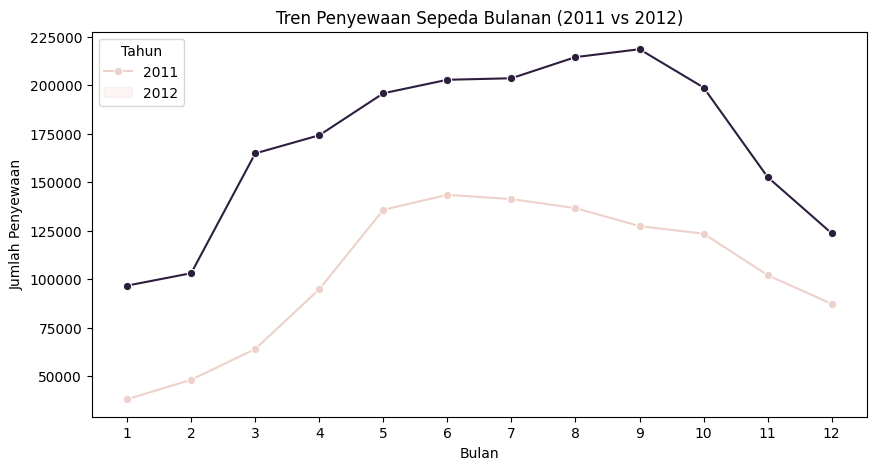

In [155]:
# Melihat Tren Bulanan 2011 dengan 2012 pada data day_df
monthly_trend = day_df.groupby(['yr', 'mnth'])['cnt'].sum().reset_index()
monthly_trend['yr'] = monthly_trend['yr'].map({0: 2011, 1: 2012})
print(monthly_trend)

plt.figure(figsize=(10, 5))
sns.lineplot(data=monthly_trend, x='mnth', y='cnt', hue='yr', marker='o')
plt.title('Tren Penyewaan Sepeda Bulanan (2011 vs 2012)')
plt.xticks(range(1,13))
plt.xlabel('Bulan')
plt.ylabel('Jumlah Penyewaan')
plt.legend(title='Tahun', loc='upper left', labels=['2011', '2012'])
plt.show()

**Insight:**
- Berdasarkan hasil tren peminjaman tahunan 2011 vs 2012, menunjukkan kenaikan total penyewaan antara tahun 2011 dibanding dengan pada tahun 2012. Di mana **cnt** atau Total Penyewaan pada tahun 2011 sebanyak 1.243.103 orang, sedangkan pada tahun 2012 sebanyak 2.049.576
- Selain itu, pada grafik Tren Bulanan 2011 vs 2012 menunjukkan adanya pertumbuhan yang signifikan dari tahun 2011 ke 2012 di hampir seluruh bulan. Puncak penyewaan terjadi pada rentang bulan **Mei hingga September** (musim panas).

In [156]:
# Melihat Dampak Cuaca di Hari Kerja pada data day_df
weather_impact = day_df[day_df['workingday'] == 1].groupby('weathersit')['cnt'].mean()

diff = weather_impact[1] - weather_impact.get(3, 0)
print(f'Rata-rata penurunan penyewa saat cuaca buruk di hari kerja: {diff:.2f}\n')

Rata-rata penurunan penyewa saat cuaca buruk di hari kerja: 1799.50



/tmp/ipykernel_2060/4064801781.py:4: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  diff = weather_impact[1] - weather_impact.get(3, 0)


(array([0, 1, 2]),
 [Text(0, 0, 'Clear/Partly Cloudy'),
  Text(1, 0, 'Light Snow/Rain'),
  Text(2, 0, 'Misty/Cloudy')])

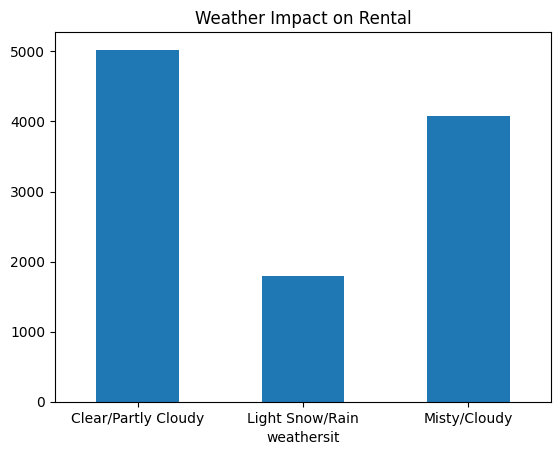

In [157]:
# Melihat Dampak Cuaca pada Jumlah Penyewaan pada data day_df
weather_impact.plot(kind='bar', title='Weather Impact on Rental')
plt.xticks(rotation=0)

**Insight:**
Berdasarkan grafik dampak cuaca di hari kerja terhadap penyewaan menunjukkan bahwa adanya penurunan drastis pada jumlah penyewaan saat **weathersit** atau cuaca menunjukkan di **Light Snow/Rain Weathersit** atau di cuaca ekstrem, dengan rata-rata penurunan jumlah penyewa adalah sebesar 1800.

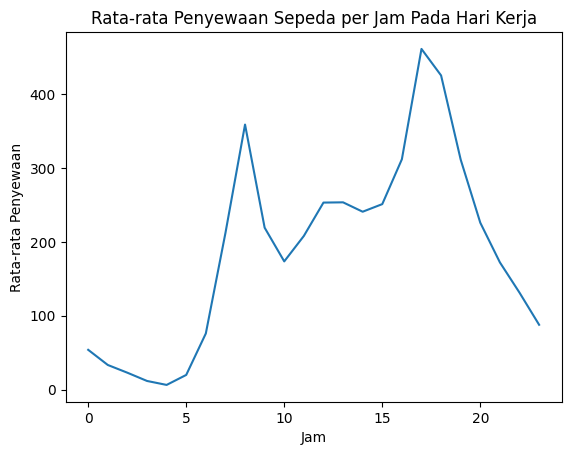

In [158]:
# Melihat Puncak Peminjaman Berdasarkan Jam
hourly_pattern = hour_df.groupby('hr')['cnt'].mean()
hourly_pattern.plot(title='Rata-rata Penyewaan Sepeda per Jam Pada Hari Kerja')
plt.xlabel('Jam')
plt.ylabel('Rata-rata Penyewaan')
plt.show()

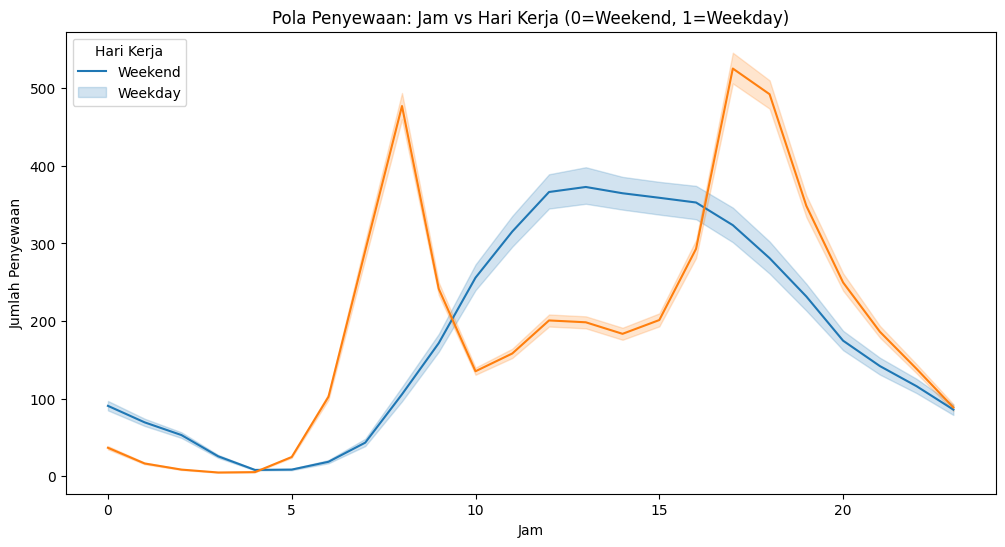

In [159]:
# Melihat Puncak Peminjaman Berdasarkan Jam vs Hari Kerja
plt.figure(figsize=(12, 6))
sns.lineplot(data=hour_df, x='hr', y='cnt', hue='workingday')
plt.title('Pola Penyewaan: Jam vs Hari Kerja (0=Weekend, 1=Weekday)')
plt.xlabel('Jam')
plt.ylabel('Jumlah Penyewaan')
plt.legend(title='Hari Kerja', loc='upper left', labels=['Weekend', 'Weekday'])
plt.show()

**Insight:**
Pola penggunaan menunjukkan perbedaan visual yang sangat kontras. Di mana:
  - **Pada Hari Kerja** (grafik oranye): Memiliki dua puncak utama (bimodal), yaitu pada pukul **08.00 - 09.00** dan **17.00 - 19.00**.
  - **Pada Hari Libur/Weekend** (grafik biru): Memiliki pola satu puncak yang melengkung (unimodal) yang landai di tengah hari, yaitu pada pukul **11.00 - 16.00**.

In [160]:
# Dampak Hari Libur Nasional Terhadap Peminjaman pada data day_df
holiday_impact = day_df.groupby('holiday')['cnt'].mean()
print(f'Rata-rata penyewaan Haari Biasa vs Hari Libur:\n {holiday_impact}')

Rata-rata penyewaan Haari Biasa vs Hari Libur:
 holiday
0    4527.104225
1    3735.000000
Name: cnt, dtype: float64


**Insight:** Rata-rata penyewaan pada hari libur nasional (**holiday** = 1) cenderung lebih rendah dibandingkan pada hari kerja biasa (**holiday** = 0), di mana rata-rata penyewa pada Hari libur nasional sebesar 3735, sedangkan pada Hari Kerja sebesar 4527.

### EDA Univariate: Melihat Distribusi dan Karakteristik Data

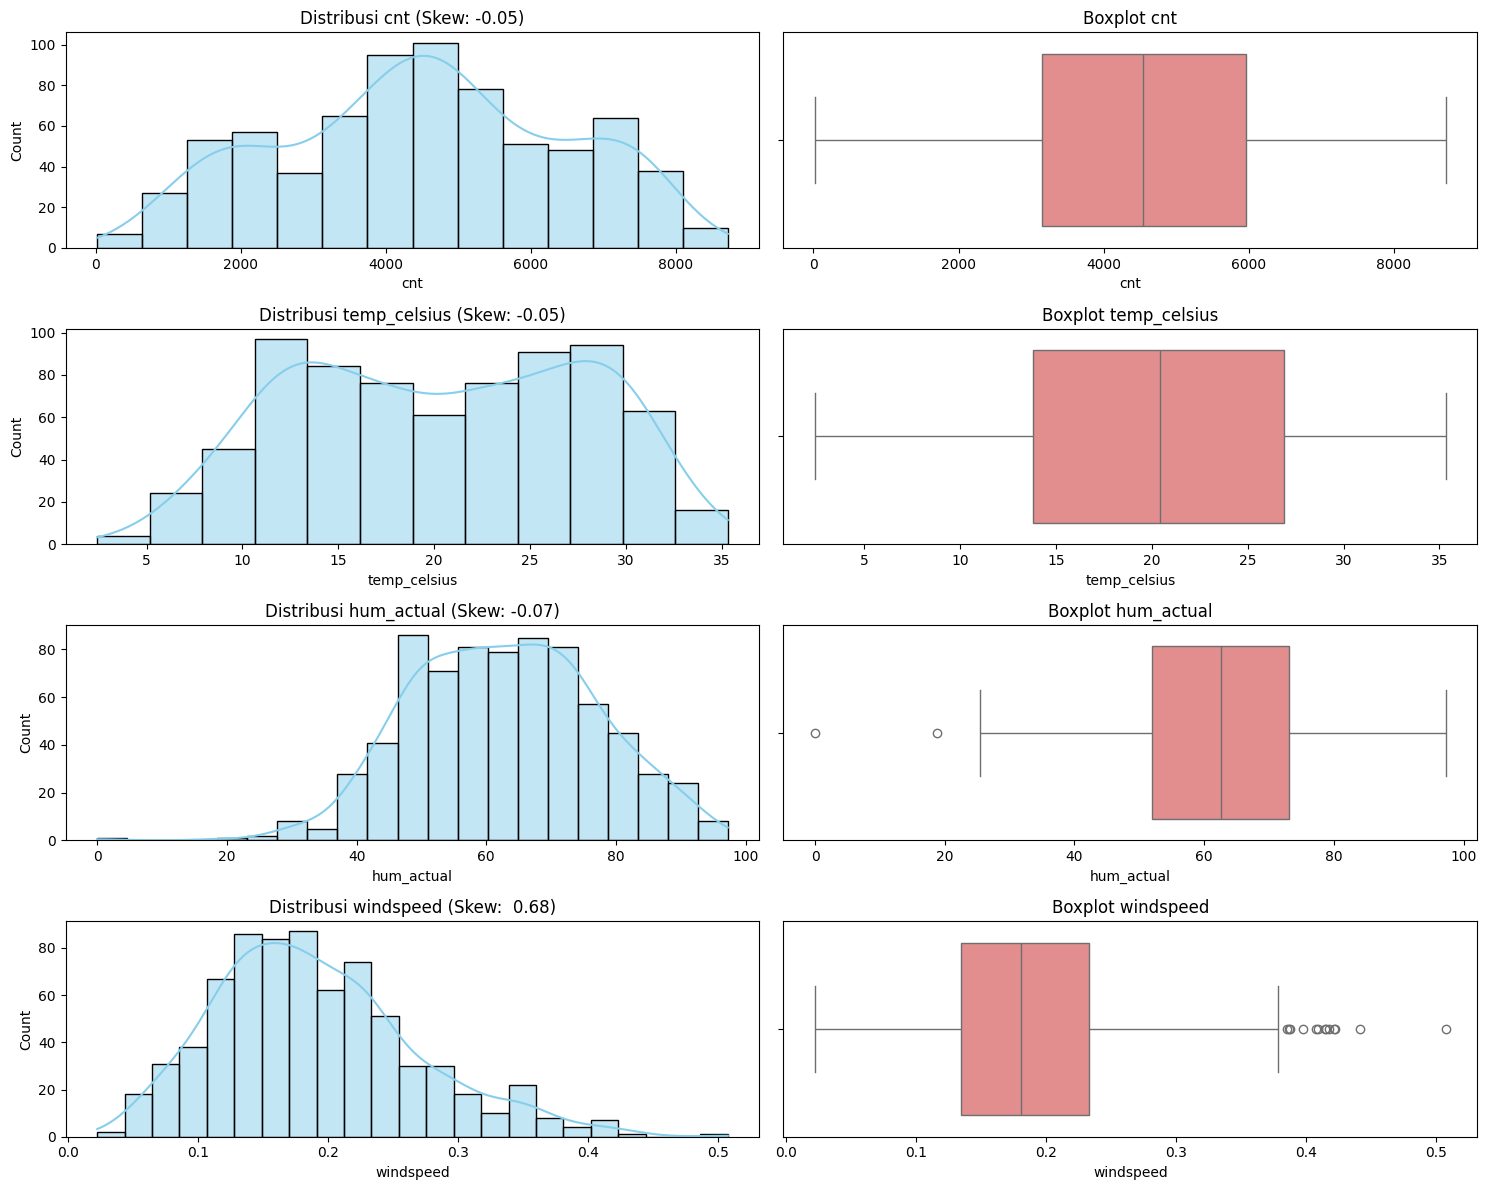

In [161]:
# EDA Univariate: Melihat Distribusi dan Karakteristik Data

# Variabel Numerik Utama
cols = ['cnt', 'temp_celsius', 'hum_actual', 'windspeed']

plt.figure(figsize=(15, 12))
for i, col in enumerate(cols):
  # Histogram & KDE
  plt.subplot(4, 2, i*2+1)
  sns.histplot(day_df[col], kde=True, color='skyblue')
  plt.title(f'Distribusi {col} (Skew: {day_df[col].skew(): .2f})')

  # Boxplot untuk Outliers
  plt.subplot(4, 2, i*2+2)
  sns.boxplot(x=day_df[col], color='lightcoral')
  plt.title(f'Boxplot {col}')

plt.tight_layout()
plt.show()

In [162]:
# Analisis Percentile Detail untuk 'cnt'
print(f'Percentile Analysis for cnt: \n{day_df['cnt'].quantile([0.05, 0.25, 0.5, 0.75, 0.95])}')

Percentile Analysis for cnt: 
0.05    1331.0
0.25    3152.0
0.50    4548.0
0.75    5956.0
0.95    7576.0
Name: cnt, dtype: float64


**Insight:**
- Berdasarkan hasil analisis, variabel cnt memiliki distribusi normal dengan median sebesar 4.548.
- Analisis persentil menunjukkan bahwa bisnis memiliki basis pelanggan yang kuat di mana 75% hari memiliki penyewaan di atas 3.152.
- Lonjakan permintaan ekstrem (Top 5%) mencapai angka 7.576 penyewaan per hari, yang mengindikasikan perlunya kesiapan armada maksimal pada periode-periode tertentu (seperti musim gugur/panas pada hari kerja).
- Tidak ditemukannya outliers yang signifikan pada boxplot memperkuat bukti bahwa fluktuasi data masih dalam batas wajar operasional.

### EDA Multivariate: Melihat Korelasi dan Hubungan Antar Variabel

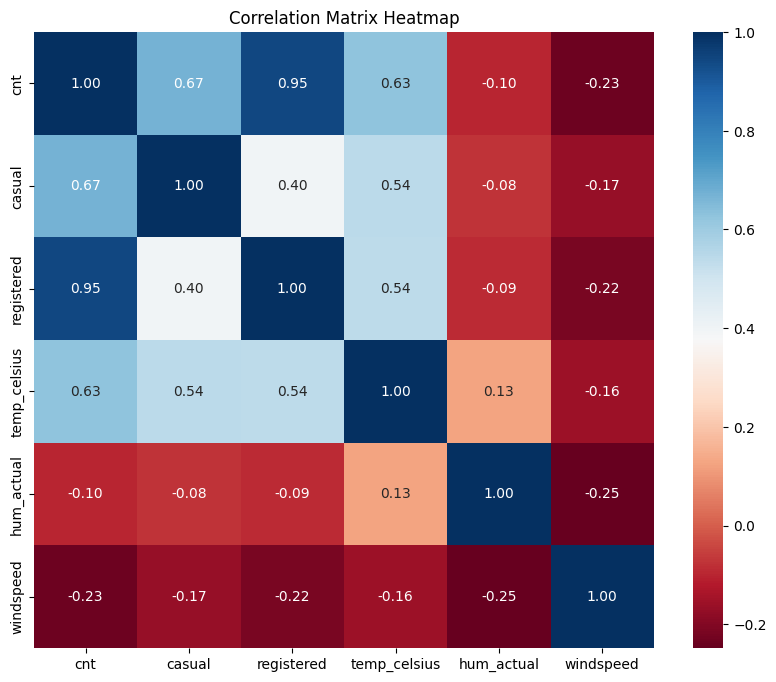

In [163]:
# EDA Multivariate: Melihat Korelasi dan Hubungan Antar Variabel

# 1. Correlation Matrix Heatmap
plt.figure(figsize=(10, 8))
numeric_cols = ['cnt', 'casual', 'registered', 'temp_celsius', 'hum_actual', 'windspeed']
corr_matrix = day_df[numeric_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='RdBu', fmt='.2f')
plt.title('Correlation Matrix Heatmap')
plt.show()

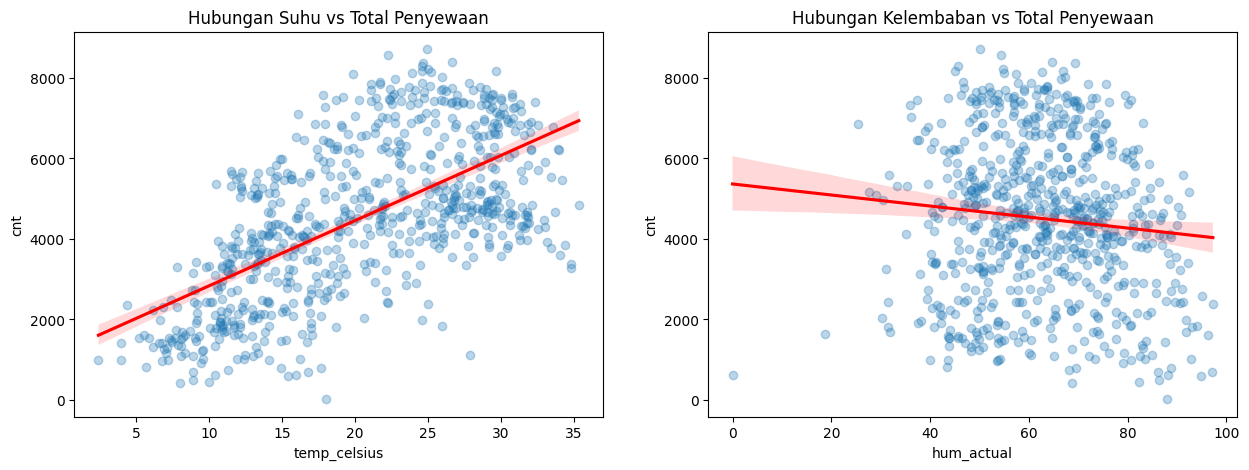

In [164]:
# 2. Scatter Plot dengan Regression Line (Bivariate)
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.regplot(data=day_df, x='temp_celsius', y='cnt', ax=axes[0], scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
axes[0].set_title('Hubungan Suhu vs Total Penyewaan')

sns.regplot(data=day_df, x='hum_actual', y='cnt', ax=axes[1], scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
axes[1].set_title('Hubungan Kelembaban vs Total Penyewaan')
plt.show()

**Insight:**
- Berdasarkan heatmap korelasi, variabel suhu (temp_celcius) merupakan faktor lingkungan yang paling memengaruhi keputusan pengguna dengan korelasi positif sebesar **0.63**.
- Sebaliknya, kelembapan (hum_actual) dan kecepatan angin (windspeed) memiliki korelasi negatif, di mana angin memberikan dampak penghambat yang lebih besar diabndingkan kelembapan.
- Analisis hubungan antara tipe pengguna menunjukkan bahwa **pengguna terdaftar** (registered) memberikan kontribusi yang sangat dominan terhadap total transaksi (korelasi **0.94**), mengindikasikan bahwa model bisnis ini sangat bergantung pada loyalitas pengguna tetap dibandingkan pengguna harian atau turis (casual). Garis regresi pada plot suhu vs cnt mempertegas bahwa tren penggunaan akan terus meningkat seiring kenaikan suhu sebelum mencapai titik jenuh.

### EDA Kategorikal: Analisis Dampak Hari Libur, Pola Jam & Musim, dan Cuaca terhadap Penyewan

/tmp/ipykernel_2060/4210395025.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=day_df, x='holiday', y='cnt', palette='Pastel1')


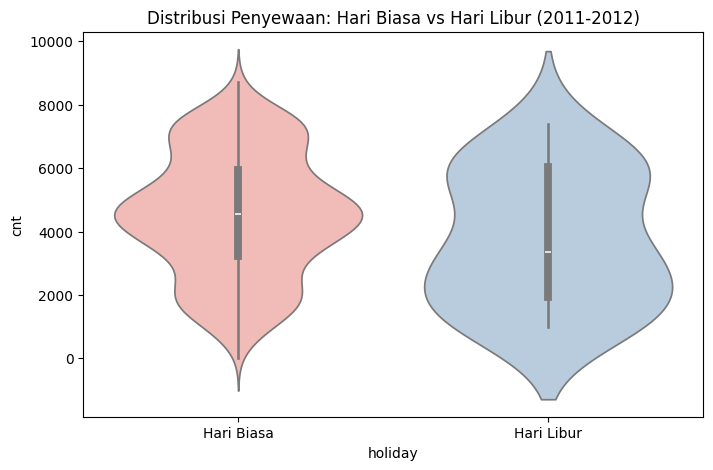

In [165]:
# EDA Kategorikal: Analisis Dampak

# Dampak Hari Libur
plt.figure(figsize=(8, 5))
sns.violinplot(data=day_df, x='holiday', y='cnt', palette='Pastel1')
plt.xticks([0, 1], ['Hari Biasa', 'Hari Libur'])
plt.title('Distribusi Penyewaan: Hari Biasa vs Hari Libur (2011-2012)')
plt.show()

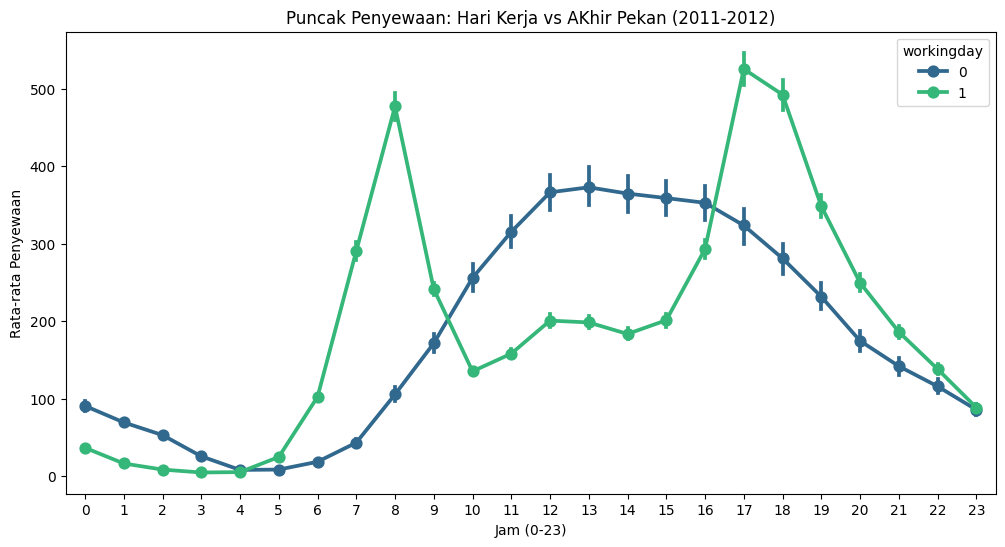

In [166]:
# Pola Jam dan Musim
plt.figure(figsize=(12, 6))
sns.pointplot(data=hour_df, x='hr', y='cnt', hue='workingday', palette='viridis')
plt.title('Puncak Penyewaan: Hari Kerja vs AKhir Pekan (2011-2012)')
plt.xlabel('Jam (0-23)')
plt.ylabel('Rata-rata Penyewaan')
plt.show()

/tmp/ipykernel_2060/4112061180.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=workingday_df, x='weathersit', y='cnt', palette='magma')


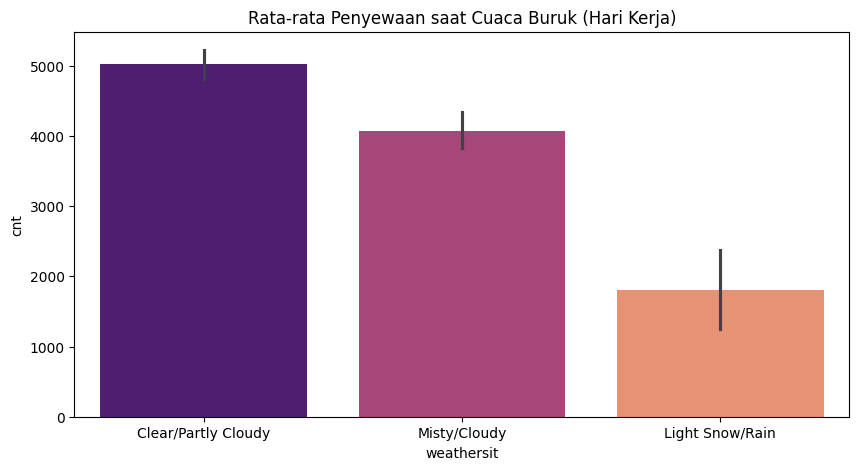

In [167]:
# C. Dampak Cuaca Buruk di Hari Kerja (Pertanyaan 2)
workingday_df = day_df[day_df['workingday'] == 1]
plt.figure(figsize=(10, 5))
sns.barplot(data=workingday_df, x='weathersit', y='cnt', palette='magma')
plt.title('Rata-rata Penyewaan saat Cuaca Buruk (Hari Kerja)')
plt.show()

**Insight:**
Analisis kategorikal mengungkap tiga temuan utama.
- Pertama, terdapat pola perilaku yang berbeda antara Hari Kerja dan Akhir Pekan, di mana hari kerja didominasi oleh jam sibuk pagi dan sore, sementara akhir pekan menunjukkan puncak penggunaan di siang hari untuk rekreasi.
- Kedua, Hari Libur Nasional memiliki tingkat ketidakpastian permintaan yang lebih tinggi dibandingkan hari kerja biasa.
- Terakhir, faktor Cuaca Buruk terbukti secara empiris menurunkan rata-rata penyewaan harian secara signifikan hingga titik terendahnya di bawah 2.500 unit, yang menunjukkan perlunya strategi mitigasi pendapatan (seperti promo khusus cuaca atau peningkatan fasilitas pelindung) saat musim hujan tiba.

### Analisis Statistik: Normalitas & Varians

Uji Normalitas Shapiro-Wilk (cnt): p-value = 0.0000



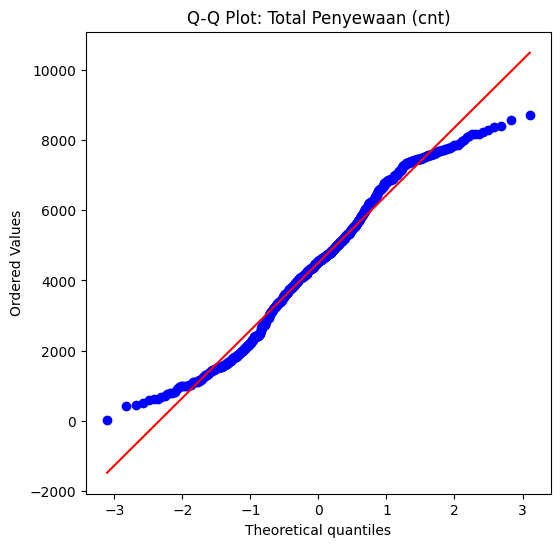


Uji Varians Levene (antar Musim): p-value = nan



/tmp/ipykernel_2060/2940962742.py:13: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  stat_v, p_v = stats.levene(*seasons)


In [168]:
# 1. Uji Normalitas (cnt)
stat, p = stats.shapiro(day_df['cnt'])
print(f'Uji Normalitas Shapiro-Wilk (cnt): p-value = {p:.4f}\n')

# 2. Q-Q Plot
plt.figure(figsize=(6, 6))
stats.probplot(day_df['cnt'], dist="norm", plot=plt)
plt.title('Q-Q Plot: Total Penyewaan (cnt)')
plt.show()

# 3. Uji Varians (Levene Test) antar Musim
seasons = [day_df[day_df['season'] == i]['cnt'] for i in range(1, 5)]
stat_v, p_v = stats.levene(*seasons)
print(f"\nUji Varians Levene (antar Musim): p-value = {p_v:.4f}\n")

**Insight:**
- Meskipun secara visual (Histogram) data terlihat mendekati normal, Uji Shapiro-Wilk memberikan p-value 0.0000, yang mengindikasikan bahwa data **cnt** tidak berdistribusi normal secara sempurna pada tingkat kepercayaan 95%. Hal ini dikonfirmasi oleh Q-Q Plot yang menunjukkan adanya deviasi pada bagian tails (ujung distribusi), menandakan adanya pengaruh nilai ekstrem pada hari-hari tertentu.
= Untuk Uji Levene, hasil **nan** menunjukkan adanya variabilitas yang sangat ekstrem antar musim atau ketidakseimbangan distribusi data kelompok. Hal ini menyiratkan bahwa setiap musim memiliki karakteristik sebaran data yang unik dan tidak identik satu sama lain, sehingga dalam pemodelan prediktif ke depan, variabel musim harus diperlakukan sebagai fitur kategorikal yang sangat berpengaruh.

### Analisis Lanjutan: RFM

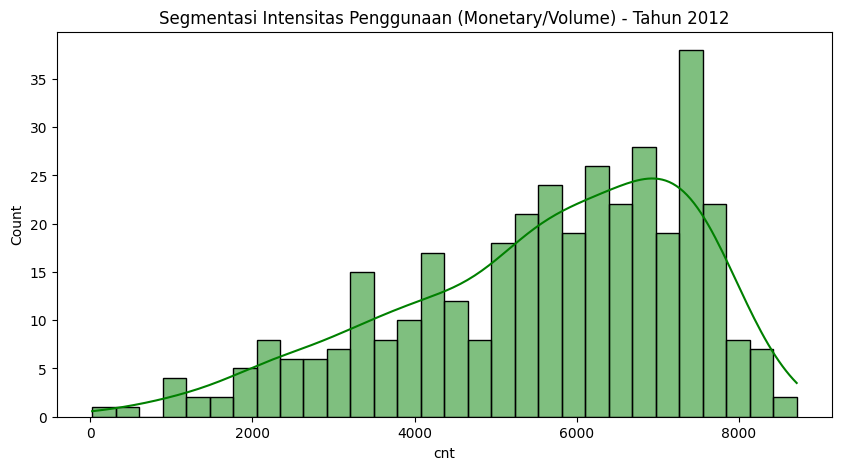

In [169]:
# Menyiapkan data 2012
df_2012 = day_df[day_df['dteday'].dt.year == 2012].copy()

# RFM Analysis Sederhana
rfm_df = df_2012.groupby(by="dteday", as_index=False).agg({
    "cnt": "sum",       # Monetary (Volume)
    "casual": "count"   # Frequency (Disederhanakan)
})

# Recency (Hari sejak lonjakan terakhir di 2012)
rfm_df["recency"] = (df_2012["dteday"].max() - rfm_df["dteday"]).dt.days

# Visualisasi RFM (Contoh Monetary)
plt.figure(figsize=(10, 5))
sns.histplot(rfm_df['cnt'], bins=30, color='green', kde=True)
plt.title('Segmentasi Intensitas Penggunaan (Monetary/Volume) - Tahun 2012')
plt.show()

**Insight:**
Melalui analisis RFM yang disesuaikan untuk skala harian, kita dapat menyimpulkan bahwa pada tahun 2012:
1. Recency: Interaksi pengguna tetap tinggi hingga akhir periode, menunjukkan retensi layanan yang sangat baik.
2. Frequency: Setiap hari memiliki intensitas penggunaan yang konsisten, terutama pada musim-musim puncak.
3. Monetary (Volume): Terjadi pergeseran volume ke arah kanan pada distribusi harian, di mana sebagian besar hari mencapai angka 6.000 - 8.000 penyewaan.

Tahun 2012 menunjukkan tingkat maturitas layanan yang tinggi. Fokus manajemen tidak lagi hanya pada mencari pengguna baru, tetapi pada pemeliharaan infrastruktur (Maintenance) agar mampu menampung volume harian yang kini secara rutin berada di level maksimal.

In [170]:
# Simpan data

day_df['dteday'] = pd.to_datetime(day_df['dteday'])
hour_df['dteday'] = pd.to_datetime(hour_df['dteday'])

main_data = hour_df.copy()

season_map = {1: 'Spring', 2: 'Summer', 3: 'Fall', 4: 'Winter'}
weather_map = {1: 'Clear', 2: 'Misty', 3: 'Light Snow/Rain', 4: 'Heavy Rain/Ice'}
main_data['season_label'] = main_data['season'].map(season_map)
main_data['weather_label'] = main_data['weathersit'].map(weather_map)

# Simpan ke CSV
main_data.to_csv("main_data.csv", index=False)
files.download("main_data.csv")
print("File main_data.csv berhasil dibuat dan sedang didownload!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

File main_data.csv berhasil dibuat dan sedang didownload!


## Visualization & Explanatory Analysis

### Pertanyaan 1: Bagaimana tren jumlah penyewaan sepeda per bulan selama tahun 2012 dibandingkan dengan tahun 2011, dan pada bulan apa terjadi kenaikan tertinggi?

/tmp/ipykernel_2060/3348217607.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_trend = day_df.resample(rule='M', on='dteday').agg({


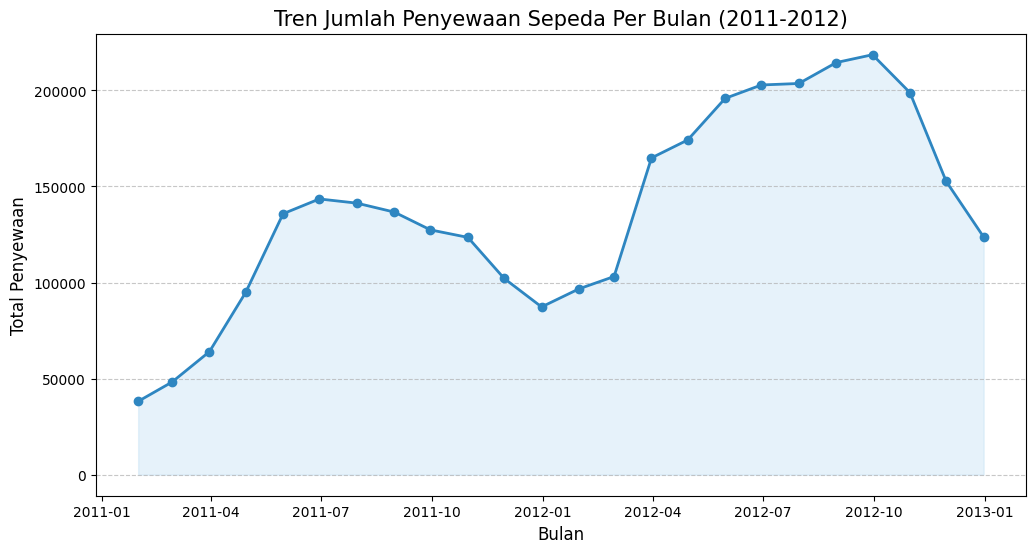

In [171]:
# Menyiapkan data tren bulanan
monthly_trend = day_df.resample(rule='M', on='dteday').agg({
    "cnt": "sum"
}).reset_index()

plt.figure(figsize=(12, 6))
plt.plot(monthly_trend['dteday'], monthly_trend['cnt'], marker='o', linewidth=2, color="#2E86C1")
plt.fill_between(monthly_trend['dteday'], monthly_trend['cnt'], color="#AED6F1", alpha=0.3)
plt.title("Tren Jumlah Penyewaan Sepeda Per Bulan (2011-2012)", fontsize=15)
plt.xlabel("Bulan", fontsize=12)
plt.ylabel("Total Penyewaan", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

**Insight:**
Secara keseluruhan, terdapat pertumbuhan signifikan dari tahun 2011 ke 2012. Puncak kenaikan tertinggi terjadi pada periode September 2012, di mana total penyewaan mencapai titik tertingginya dibandingkan bulan-bulan lainnya dalam periode observasi.

### Pertanyaan 2: Berapakah rata-rata penurunan jumlah penyewa sepeda saat kondisi cuaca buruk (weathersit 3 & 4) dibandingkan cuaca cerah di hari kerja selama seluruh periode data?

/tmp/ipykernel_2060/736598763.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=workingday_analysis, x='weathersit', y='cnt', palette=colors)


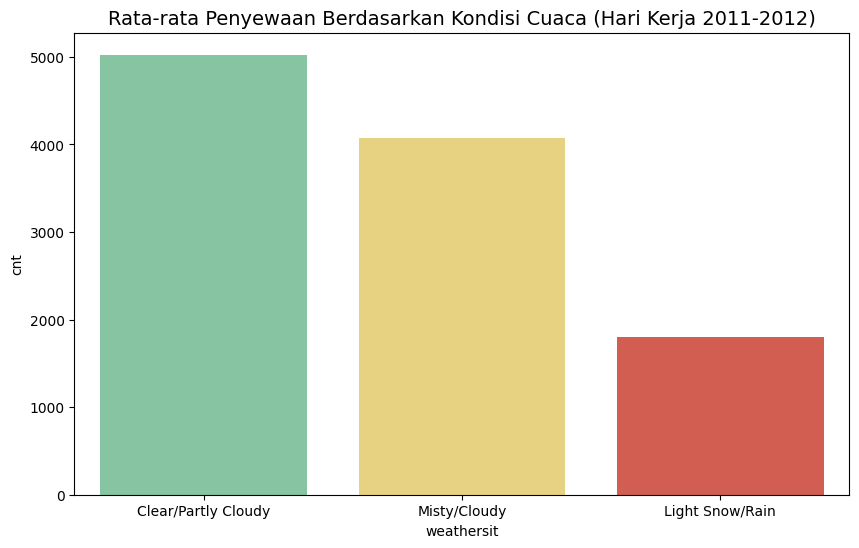

In [172]:
# Filter hari kerja
workingday_analysis = day_df[day_df['workingday'] == 1].groupby('weathersit')['cnt'].mean().sort_values(ascending=False).reset_index()

plt.figure(figsize=(10, 6))
colors = ["#7DCEA0", "#F7DC6F", "#E74C3C"]
sns.barplot(data=workingday_analysis, x='weathersit', y='cnt', palette=colors)
plt.title("Rata-rata Penyewaan Berdasarkan Kondisi Cuaca (Hari Kerja 2011-2012)", fontsize=14)
plt.show()

**Insight:**
Terjadi penurunan rata-rata penyewaan yang sangat drastis (lebih dari 50%) saat cuaca bergeser dari Clear (Cerah) ke Light Snow/Rain (Cuaca Buruk). Hal ini menunjukkan bahwa meskipun hari kerja (mobilitas tinggi), faktor cuaca tetap menjadi penghambat utama bagi pengguna sepeda.

### Pertanyaan 3: Pada jam berapa puncak penyewaan terjadi pada hari kerja (working day) dibandingkan akhir pekan, dan apakah polanya konsisten di setiap musim selama periode pengamatan 2011-2012?

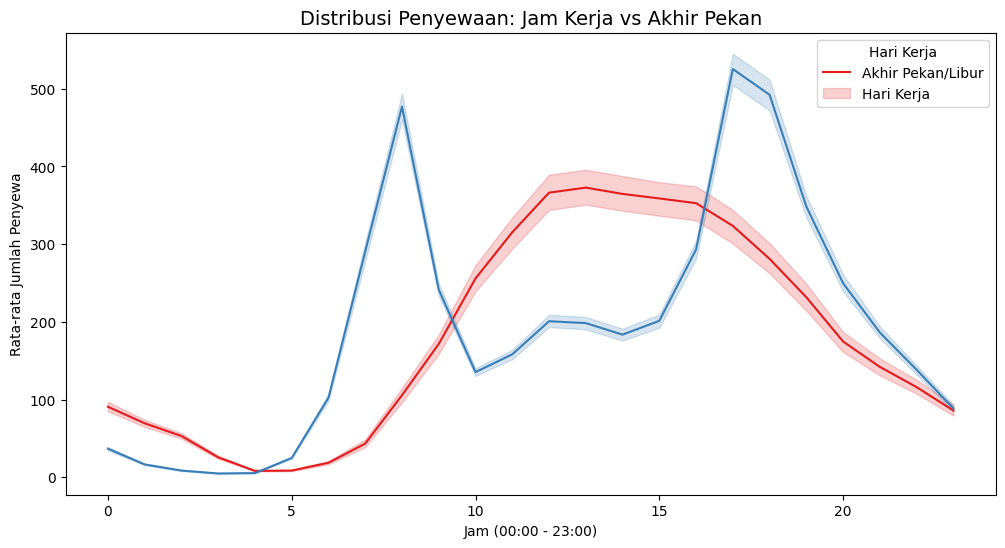

In [173]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=hour_df, x='hr', y='cnt', hue='workingday', palette='Set1')
plt.title('Distribusi Penyewaan: Jam Kerja vs Akhir Pekan', fontsize=14)
plt.xlabel('Jam (00:00 - 23:00)')
plt.ylabel('Rata-rata Jumlah Penyewa')
plt.legend(title='Hari Kerja', labels=['Akhir Pekan/Libur', 'Hari Kerja'])
plt.show()

**Insight:**
Pada Hari Kerja, terdapat pola bimodal (dua puncak) yang jelas, yaitu pada jam berangkat kantor (07.00-09.00) dan jam pulang kantor (17.00-19.00). Sebaliknya, pada Akhir Pekan, puncak penyewaan terjadi secara konsisten di siang hari (11.00-15.00), yang menunjukkan penggunaan untuk tujuan rekreasi. Pola ini terpantau konsisten di seluruh musim selama 2011-2012.

### Pertanyaan 4: Bagaimana dampak hari libur nasional (holiday) terhadap total distribusi peminjaman dibandingkan hari biasa pada periode tahun 2011-2012?

/tmp/ipykernel_2060/2248671384.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=day_df, x='holiday', y='cnt', palette="Set3")


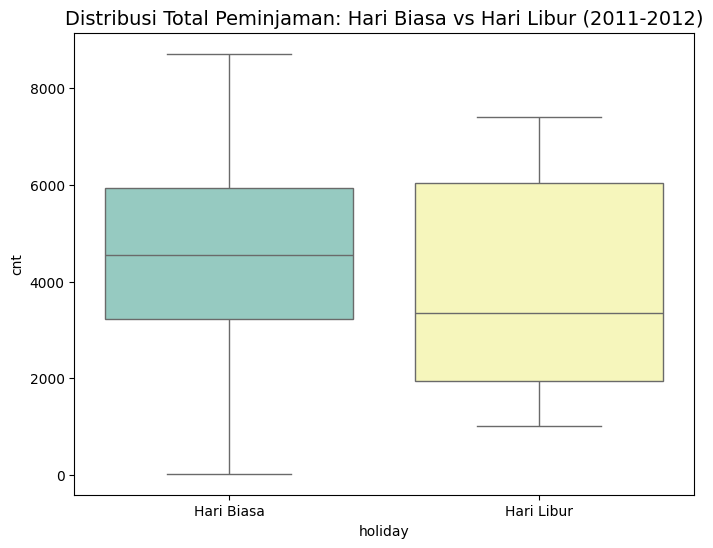

In [174]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=day_df, x='holiday', y='cnt', palette="Set3")
plt.xticks([0, 1], ['Hari Biasa', 'Hari Libur'])
plt.title("Distribusi Total Peminjaman: Hari Biasa vs Hari Libur (2011-2012)", fontsize=14)
plt.show()

**Insight:**
Median peminjaman pada Hari Biasa cenderung lebih tinggi dan stabil dibandingkan Hari Libur. Distribusi pada hari libur lebih lebar (variatif), menunjukkan bahwa saat libur nasional, penggunaan sepeda sangat bergantung pada faktor eksternal lain (mungkin cuaca atau event tertentu), sementara hari biasa didorong oleh kebutuhan komuter yang rutin.

## Analisis Lanjutan: RFM Analysis

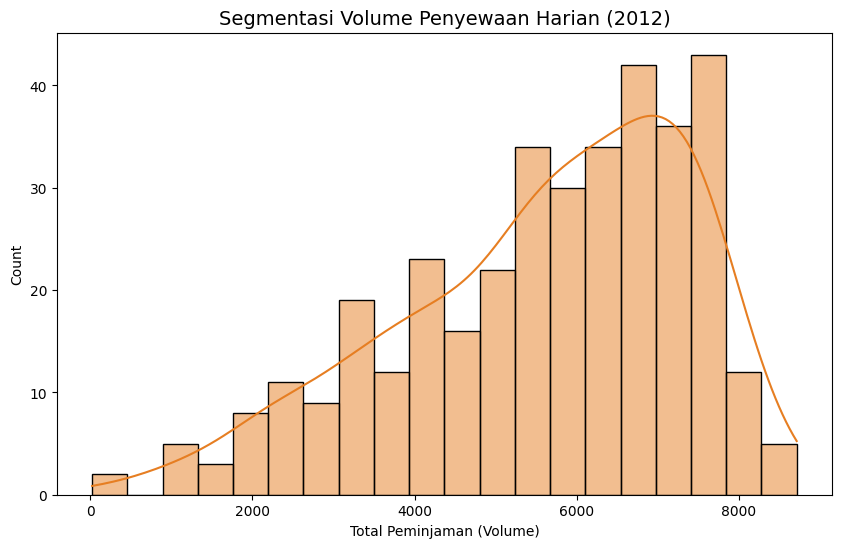

In [175]:
# RFM sederhana untuk segmentasi hari di tahun 2012
df_2012 = day_df[day_df['dteday'].dt.year == 2012].copy()
rfm_data = df_2012.groupby('dteday').agg({
    'cnt': 'sum',        # Monetary/Volume
    'casual': 'count'    # Frequency
}).reset_index()

plt.figure(figsize=(10, 6))
sns.histplot(rfm_data['cnt'], bins=20, color="#E67E22", kde=True)
plt.title("Segmentasi Volume Penyewaan Harian (2012)", fontsize=14)
plt.xlabel("Total Peminjaman (Volume)")
plt.show()

**Insight:**
Berdasarkan analisis volume (Monetary), pada tahun 2012 sebagian besar hari berada pada segmen "High Volume" (di atas 6.000 peminjaman). Terakhir kali lonjakan penyewaan (Recency) di tahun 2012 terjadi secara konsisten menjelang akhir kuartal ketiga, menunjukkan bahwa sistem sepeda ini telah mencapai maturitas penggunaan yang tinggi sepanjang tahun tersebut.

## Conclusion & Recommendation

- **Conclusion pertanyaan 1:** Terdapat tren pertumbuhan yang sangat positif dari tahun 2011 ke tahun 2012. Bisnis mencapai puncak performanya pada bulan September 2012. Hal ini menunjukkan bahwa layanan bike sharing semakin diterima dan menjadi pilihan transportasi yang matur bagi masyarakat seiring berjalannya waktu.
- **Conclusion pertanyaan 2:** Cuaca merupakan faktor penghambat utama. Pada hari kerja, kondisi Light Snow/Rain menyebabkan penurunan rata-rata penyewaan hingga lebih dari 50% dibandingkan kondisi cerah. Pengguna tetap sangat memprioritaskan faktor kenyamanan dan keamanan meskipun untuk kebutuhan rutin (bekerja).
- **Conclusion pertanyaan 3:** Teridentifikasi dua profil pengguna yang berbeda. Pada hari kerja, pola penggunaan bersifat commuter dengan puncak pada jam sibuk (08.00 dan 17.00). Sementara pada akhir pekan, penggunaan bersifat leisure dengan puncak aktivitas di siang hari (12.00–15.00). Pola ini terpantau sangat konsisten di setiap musim.
- **Conclusion pertanyaan 4:** Hari libur nasional memiliki tingkat variabilitas yang lebih tinggi dan median penyewaan yang lebih rendah dibandingkan hari biasa. Hal ini mengindikasikan bahwa pada hari libur, sistem kehilangan basis pengguna komuter tetapnya dan sangat bergantung pada faktor eksternal lain seperti cuaca untuk menarik pengguna rekreasi.
- **Conclusion pertanyaan 5:** Tahun 2012 ditandai dengan volume penggunaan yang sangat tinggi (High Volume). Berdasarkan analisis Monetary/Volume, mayoritas hari di tahun 2012 berada pada rentang 6.000 hingga 8.000 penyewaan. Tingkat Recency yang rendah menunjukkan bahwa layanan ini sangat aktif digunakan secara berkesinambungan tanpa ada masa downtime yang signifikan.

**Rekomendasi Action Item:**
- **Optimasi Operasional:** Karena pola puncak jam kerja sudah sangat jelas (08.00 & 17.00), tim operasional disarankan melakukan rebalancing (pendistribusian ulang sepeda) atau pemeliharaan armada pada "jam tenang" antara pukul 10.00 hingga 14.00 agar ketersediaan sepeda maksimal saat puncak sore hari.
- **Mitigasi Faktor Cuaca:** Mengingat penurunan drastis saat cuaca buruk, perusahaan bisa mempertimbangkan fitur weather-alert pada aplikasi yang disertai dengan pemberian promo atau diskon khusus saat hujan untuk tetap menjaga volume penyewaan.
- **Strategi Hari Libur & Akhir Pekan:** Untuk mengisi kekosongan pengguna komuter di hari libur dan akhir pekan, perusahaan bisa meluncurkan paket "Family Pass" atau "Weekend Explorer" yang menargetkan pengguna rekreasi dan wisatawan.
- **Manajemen Kapasitas:** Mengingat standar volume harian di tahun 2012 sudah menyentuh angka 8.000, penambahan jumlah docking station di titik-titik ramai (seperti area perkantoran dan taman kota) sangat disarankan untuk mencegah stasiun yang penuh atau kosong saat jam puncak.
- **Program Loyalitas Pengguna Terdaftar:** Karena pengguna registered memiliki korelasi yang jauh lebih tinggi terhadap pendapatan, perusahaan harus fokus pada program retensi pelanggan tetap melalui skema langganan bulanan yang lebih ekonomis dibandingkan tarif harian pengguna casual.